# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mouad Tazka

**Date:** September 10, 2026

See the "Question 1 Part 1" pdf in repo for Q1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gifts = pd.read_csv("./data/ForeignGifts_edu.csv")

gifts.head()

gifts["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

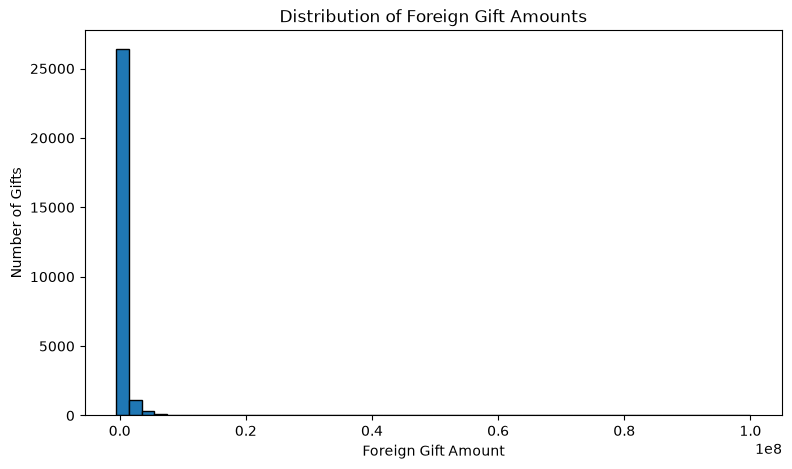

In [2]:
plt.figure(figsize=(9.0, 5.0))

plt.hist(
    gifts["Foreign Gift Amount"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Foreign Gift Amount")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts")

plt.show()

The distribution of foreign gift amounts is extremely right-skewed. Most gifts are concentrated toward the lower end of the distribution, while a small number of very large gifts extend all the way to almost 100 million dollars. The median gift is about 94,615 dollars, while the mean is much higher at about 588,233 dollars, which shows how strongly the very large gifts pull the average upward. There are also a small number of negative amounts in the dataset, with the minimum being -$537,770. Because of the extreme values, most of the observations appear compressed near the left side of the histogram.

In [3]:
gift_counts = gifts["Gift Type"].value_counts()

gift_counts

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [4]:
gift_proportions = gifts["Gift Type"].value_counts(normalize=True)

gift_proportions * 100

Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64

Contracts make up the majority of the observations, accounting for about 61.21% of all gifts. Monetary gifts account for about 38.75%, while real estate is extremely uncommon at only about 0.039% of the observations, or 11 gifts total.

In [5]:
positive_gifts = gifts[gifts["Foreign Gift Amount"] > 0].copy()

positive_gifts["Log Foreign Gift Amount"] = np.log(
    positive_gifts["Foreign Gift Amount"]
)

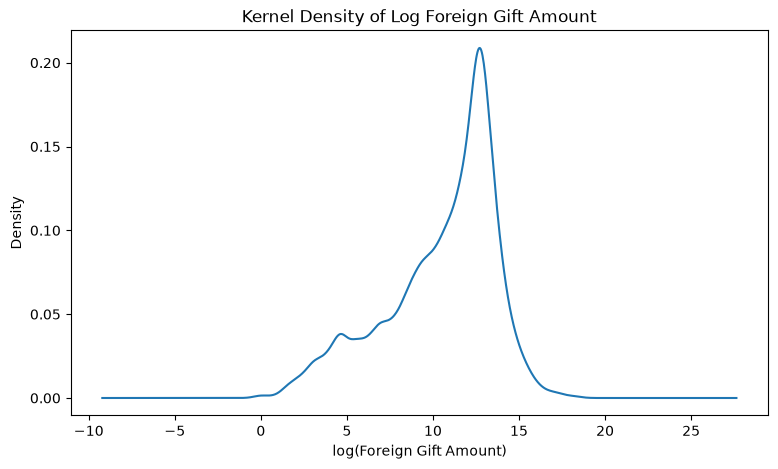

In [6]:
plt.figure(figsize=(9.0, 5.0))

positive_gifts["Log Foreign Gift Amount"].plot.kde()

plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.title("Kernel Density of Log Foreign Gift Amount")

plt.show()

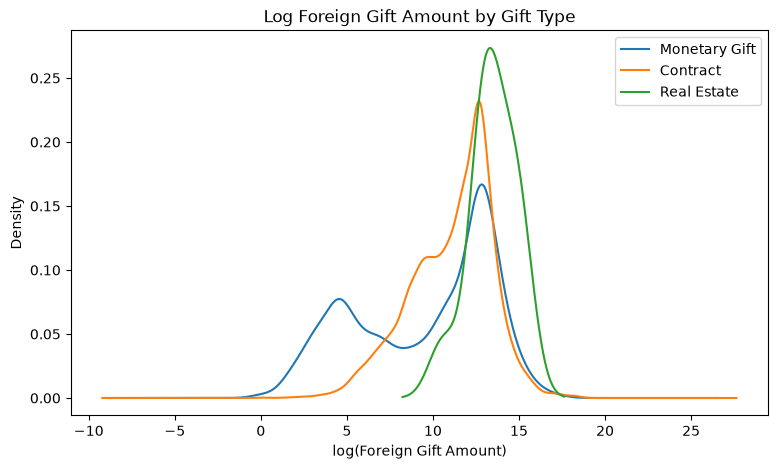

In [7]:
plt.figure(figsize=(9.0, 5.0))

for gift_type in positive_gifts["Gift Type"].unique():

    subset = positive_gifts[
        positive_gifts["Gift Type"] == gift_type
        ]

    subset["Log Foreign Gift Amount"].plot.kde(
        label=gift_type
    )

plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.title("Log Foreign Gift Amount by Gift Type")
plt.legend()

plt.show()

In [8]:
positive_gifts.groupby("Gift Type")["Foreign Gift Amount"].median()

Gift Type
Contract         110584.5
Monetary Gift     50000.0
Real Estate      667555.0
Name: Foreign Gift Amount, dtype: float64

After taking the log, the differences between the gift types are easier to see. Contracts and monetary gifts overlap quite a bit, although contracts generally tend to have larger amounts. Monetary gifts have a wider spread toward very small gift amounts, which creates more density on the left side of the plot. Real estate gifts tend to occur at larger amounts, but there are only 11 real estate observations, so I would be careful about drawing a strong conclusion from that group. Overall, the log transformation makes the distributions much less dominated by the few extremely large gifts.

In [9]:
top15_count = (
    gifts
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

top15_count

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

England has the largest number of reported gifts with 3,655, followed by China with 2,461 and Canada with 2,344. One thing to notice is that the dataset contains both "SOUTH KOREA" and "KOREA" as separate country labels, so these results use the country names exactly as they appear in the original dataset.

In [10]:
top15_amount = (
    gifts
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top15_amount

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

The ranking changes quite a bit when looking at total dollars rather than the number of gifts. Qatar gives the largest total amount at about 2.71 billion dollars, followed by England at about 1.46 billion and China at about 1.24 billion. This shows that having the most gifts does not necessarily mean contributing the most money. For example, Qatar is only 11th in the number of gifts but ranks first by total amount.

In [11]:
top_giftors = (
    gifts
    .groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_giftors

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

Using the giftor names exactly as they appear in the dataset, the Qatar Foundation provides the most money overall at about $1.17 billion. Several of the other largest giftors are also Qatar-related organizations, including "Qatar Foundation/Qatar National Res" and "Qatar Foundation for Education". The names are not completely standardized, though, so organizations that may be related are still counted separately if they have different names in the dataset.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b33ee6a102c9dd2df81d546061fa4ff5db80bdcc
- **AI tool and model used:** ChatGPT 5.6 Sol

### *Prompts used

1. Suggest any revisions for phase 1 if necessary

### *AI-proposed changes


1. Explain the log filtering: State that I restricted the KDE analysis to positive gift amounts because the natural log of negative values is not defined in the real-number setting; this removes only 24 negative observations. NumPy returns NaN for negative real inputs to np.log().
2. Make the histogram description more precise: Change “almost 100 million” to “100 million,” since that is the exact maximum value in the dataset.
3. Use .size() for counting gifts by country: Replace .count() with .size() because .size() directly counts rows in each country group, while .count() excludes missing values in the selected column.
4. Add a caveat to the giftor rankings: Mention that 3,751 observations have missing giftor names, so the ranking represents the largest identified giftors, not necessarily all sources of foreign gifts.

### *Evaluation of AI suggestions



| Change                                                                   | Decision | Reason and verification                                                                                                                                                                                                                                                                                            |
|--------------------------------------------------------------------------|----------| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 1. Explain why only positive gift amounts are used for the log/KDE analysis | Accept   | I accepted this change because `np.log()` is not valid for negative real-valued inputs. I verified that there are only 24 negative gift amounts, so filtering to positive values is necessary and removes only a very small number of observations.                                                                |
| 2. Change “almost 100 million” to “100 million”                          | Accept   | I accepted this change because the descriptive statistics show that the maximum gift amount is exactly $100,000,000. This makes the written description more precise.                                                                                                                                              |
| 3. Replace `.count()` with `.size()` when counting gifts by country      | Decline  | I decided not to change the code because `.count()` gives the correct result here and the assignment specifically suggests using `.groupby(...).count()`. However, I recognize that `.size()` would be slightly more robust because it counts all rows rather than only non-missing values in the selected column. |
| 4. Add a caveat about missing giftor names                               | Accept   | I accepted this change because 3,751 observations have missing giftor names. I added a note explaining that the ranking therefore represents the largest identified giftors rather than all sources of foreign gifts.                                                                                              |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

See the "Question 1 Part 1" pdf in repo for Q1

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gifts = pd.read_csv("./data/ForeignGifts_edu.csv")

gifts.head()

gifts["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

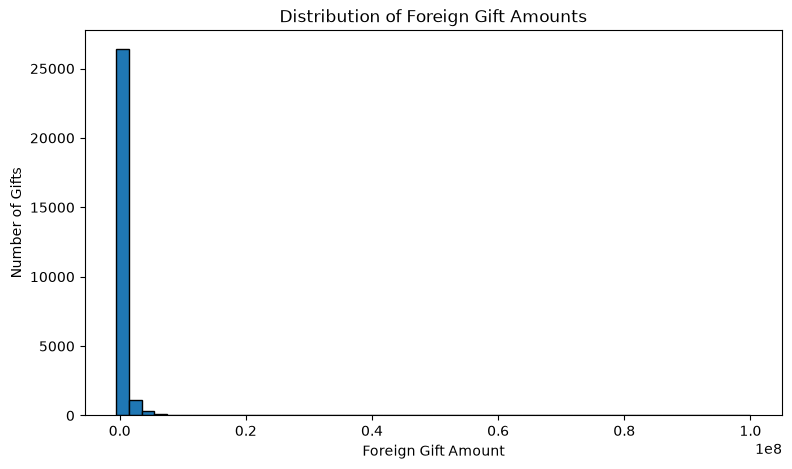

In [13]:
plt.figure(figsize=(9.0, 5.0))

plt.hist(
    gifts["Foreign Gift Amount"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Foreign Gift Amount")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts")

plt.show()

The distribution of foreign gift amounts is extremely right-skewed. Most gifts are concentrated toward the lower end of the distribution, while a small number of very large gifts extend all the way to 100 million dollars. The median gift is about 94,615 dollars, while the mean is much higher at about 588,233 dollars, which shows how strongly the very large gifts pull the average upward. There are also a small number of negative amounts in the dataset, with the minimum being -$537,770. Because of the extreme values, most of the observations appear compressed near the left side of the histogram.

In [14]:
gift_counts = gifts["Gift Type"].value_counts()

gift_counts

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [15]:
gift_proportions = gifts["Gift Type"].value_counts(normalize=True)

gift_proportions * 100

Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64

In [16]:
positive_gifts = gifts[gifts["Foreign Gift Amount"] > 0].copy()

positive_gifts["Log Foreign Gift Amount"] = np.log(
    positive_gifts["Foreign Gift Amount"]
)

Because the natural log is not defined for negative values in the real-number setting, I restricted the log analysis to positive gift amounts. There are 24 negative gift amounts in the dataset, so this removes only a very small number of observations before creating the KDE plots.

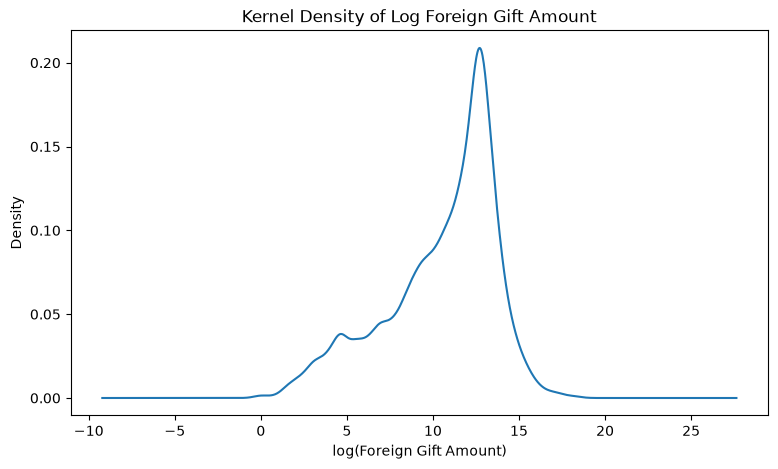

In [17]:
plt.figure(figsize=(9.0, 5.0))

positive_gifts["Log Foreign Gift Amount"].plot.kde()

plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.title("Kernel Density of Log Foreign Gift Amount")

plt.show()

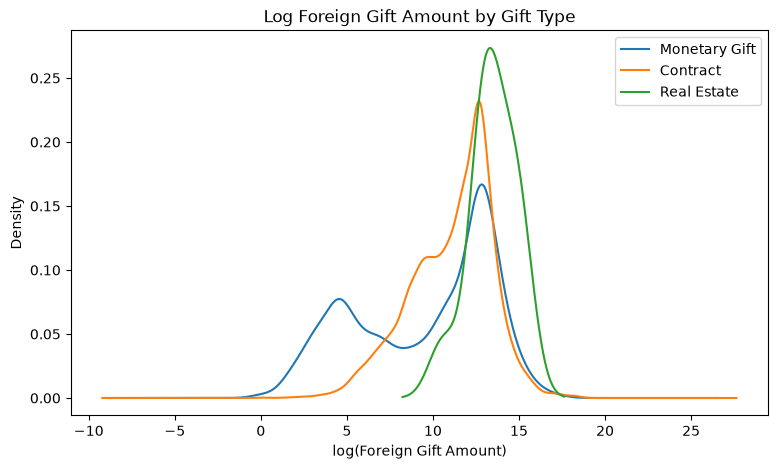

In [18]:
plt.figure(figsize=(9.0, 5.0))

for gift_type in positive_gifts["Gift Type"].unique():

    subset = positive_gifts[
        positive_gifts["Gift Type"] == gift_type
        ]

    subset["Log Foreign Gift Amount"].plot.kde(
        label=gift_type
    )

plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.title("Log Foreign Gift Amount by Gift Type")
plt.legend()

plt.show()

In [19]:
positive_gifts.groupby("Gift Type")["Foreign Gift Amount"].median()

Gift Type
Contract         110584.5
Monetary Gift     50000.0
Real Estate      667555.0
Name: Foreign Gift Amount, dtype: float64

After taking the log, the differences between the gift types are easier to see. Contracts and monetary gifts overlap quite a bit, although contracts generally tend to have larger amounts. Monetary gifts have a wider spread toward very small gift amounts, which creates more density on the left side of the plot. Real estate gifts tend to occur at larger amounts, but there are only 11 real estate observations, so I would be careful about drawing a strong conclusion from that group. Overall, the log transformation makes the distributions much less dominated by the few extremely large gifts.

In [20]:
top15_count = (
    gifts
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

top15_count

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

England has the largest number of reported gifts with 3,655, followed by China with 2,461 and Canada with 2,344. One thing to notice is that the dataset contains both "SOUTH KOREA" and "KOREA" as separate country labels, so these results use the country names exactly as they appear in the original dataset.

In [21]:
top15_amount = (
    gifts
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top15_amount

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

The ranking changes quite a bit when looking at total dollars rather than the number of gifts. Qatar gives the largest total amount at about 2.71 billion dollars, followed by England at about 1.46 billion and China at about 1.24 billion. This shows that having the most gifts does not necessarily mean contributing the most money. For example, Qatar is only 11th in the number of gifts but ranks first by total amount.

In [22]:
top_giftors = (
    gifts
    .groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_giftors

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

Using the giftor names exactly as they appear in the dataset, the Qatar Foundation provides the most money overall at about $1.17 billion. Several of the other largest giftors are also Qatar-related organizations, including "Qatar Foundation/Qatar National Res" and "Qatar Foundation for Education". The names are not completely standardized, though, so organizations that may be related are still counted separately if they have different names in the dataset. There are also 3,751 observations with a missing giftor name. Because those records are excluded when grouping by Giftor Name, this ranking represents the largest identified giftors rather than all sources of foreign gifts.

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements I made were mostly about making my explanations more precise and adding context that was missing from Phase 1. For example, I clarified why I filtered out negative gift amounts before taking the log, changed “almost 100 million” to the exact maximum of $100 million, and added a note that the giftor rankings only include identified giftors because some rows are missing a giftor name. I also reviewed the AI suggestion to replace `.count()` with `.size()` when counting gifts by country. I decided not to make that change because my original `.count()` approach gave the correct result and the assignment specifically suggested using `.groupby(...).count()`. This was a good example of an AI suggestion being technically reasonable but not actually necessary.

I verified the final solution by rerunning the descriptive statistics, value counts, grouped totals, and top-15 rankings, and by checking the number of negative gift amounts and missing giftor names directly in the dataset. I also compared the outputs to my written interpretations to make sure the numbers matched. One remaining concern is that giftor names are not standardized, so related organizations can appear as separate giftors. Also, the real estate category only has 11 observations, so I would be cautious about making strong conclusions about that group.
